In [1]:
def set_mpl_params(dpi=150, figsize=(9, 6), grid=True, font_size=16, font_family='serif'):
    """
    Function to set matplotlib parameters for plotting.

    Parameters:
    dpi (int): Dots per inch for the plot. Default is 300.
    figsize (tuple): Figure size for the plot. Default is (18, 12).
    grid (bool): Whether to show grid in the plot. Default is True.
    font_size (int): Font size for the text in the plot. Default is 16.
    font_family (str): Font family for the text in the plot. Default is 'serif'.

    Returns:
    None

    This function updates the default parameters in matplotlib's rcParams dictionary to 
    customize the look and feel of matplotlib plots. The parameters include dots per inch (dpi) 
    for plot resolution, figure size, grid visibility, font size, and font family.
    """
    import matplotlib as mpl
    mpl.rcParams['figure.dpi'] = dpi
    mpl.rcParams['figure.figsize'] = figsize
    mpl.rcParams['axes.grid'] = grid
    mpl.rcParams.update({'font.size': font_size})
    mpl.rcParams['font.family'] = font_family
set_mpl_params()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, load_digits, make_circles
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score



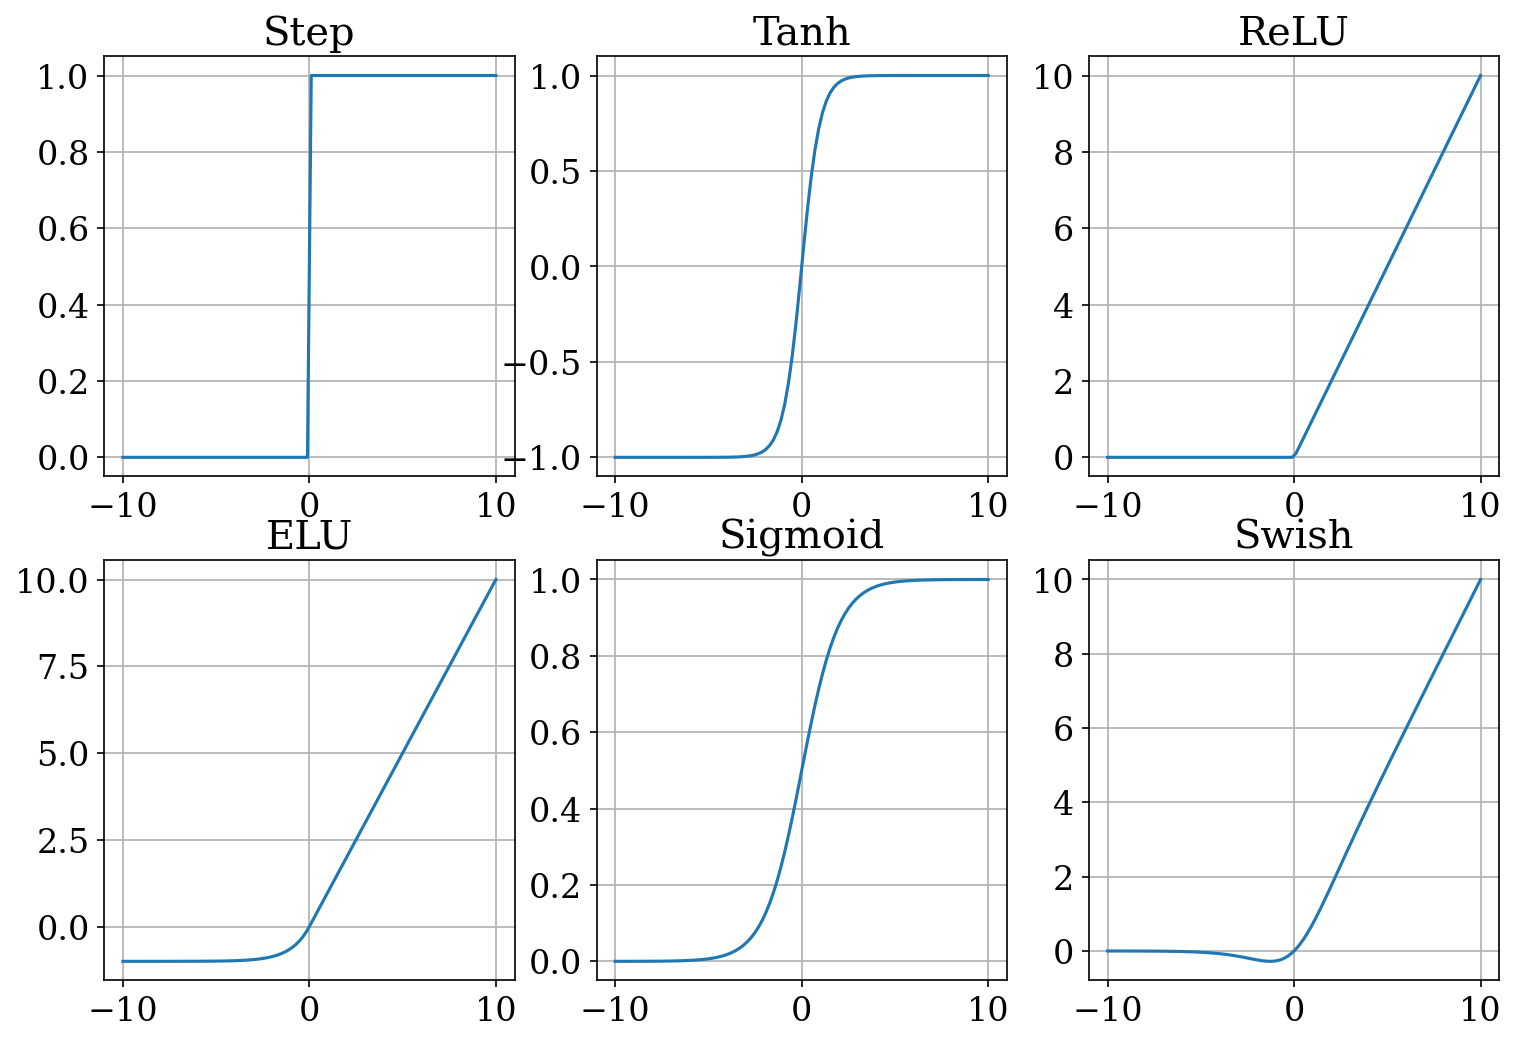

In [3]:
x = np.linspace(-10, 10, 100)

# Activation functions
def step(x):
    """Step activation function."""
    return np.where(x > 0, 1, 0)

def tanh(x):
    """Hyperbolic tangent activation function."""
    return (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))

def relu(x):
    """ReLU activation function."""
    return np.maximum(0, x)

def sigmoid(x):
    """Sigmoid (Logistic) activation function."""
    return 1 / (1 + np.exp(-x))

def elu(x, alpha=1.0):
    """Exponential Linear Unit (ELU) activation function."""
    return np.where(x > 0, x, alpha * (np.exp(x) - 1))

def swish(x, beta=1.0):
    """Swish activation function."""
    return x * sigmoid(beta * x)


# Plotting
plt.figure(figsize=(12,8))
plt.subplot(2,3,1)
plt.plot(x, step(x))
plt.title("Step")

plt.subplot(2,3,2)
plt.plot(x, tanh(x))
plt.title("Tanh")

plt.subplot(2,3,3)
plt.plot(x, relu(x))
plt.title("ReLU")

plt.subplot(2,3,4)
plt.plot(x, elu(x))
plt.title("ELU")

plt.subplot(2,3,5)
plt.plot(x, sigmoid(x))
plt.title("Sigmoid")

plt.subplot(2,3,6)
plt.plot(x, swish(x))
plt.title("Swish")
plt.show()



In [4]:
def neuron(x, w, b, activation):
    z = np.dot(w, x) + b
    return activation(z)

# Example usage
x = np.array([1.0, -2.0, 3.0])
w = np.array([0.5, -0.6, 0.2])
b = 0.1
relu = lambda z: np.maximum(0, z)

output = neuron(x, w, b, relu)
print(f"Neuron output: {output:.2f}")


Neuron output: 2.40


In [5]:
# Using neuron from Task 2
def mlp_xor(x):
    # Hidden layer weights (manually tuned)
    w1 = np.array([1.0, 1.0])  # First hidden neuron
    w2 = np.array([1.0, 1.0])  # Second hidden neuron
    b_hidden = np.array([-1.5, -0.5])
    
    # Output layer weights
    w_out = np.array([-1.0, 1.0])
    b_out = 0.0
    
    # Hidden layer
    h1 = neuron(x, w1, b_hidden[0], relu)
    h2 = neuron(x, w2, b_hidden[1], relu)
    
    # Output layer
    return sigmoid(neuron(np.array([h1, h2]), w_out, b_out, lambda z: z))

# XOR test
xor_inputs = [[0,0], [0,1], [1,0], [1,1]]
for xi in xor_inputs:
    print(f"Input {xi}: {mlp_xor(xi):.2f}")


Input [0, 0]: 0.50
Input [0, 1]: 0.62
Input [1, 0]: 0.62
Input [1, 1]: 0.73


In [6]:
def compute_gradients(network, X, y_true, learning_rate=0.1):
    # Unpack network parameters
    W1, b1, W2, b2 = network['W1'], network['b1'], network['W2'], network['b2']
    
    # Forward pass with printed values
    print("## Forward Pass ##")
    z1 = np.dot(X, W1) + b1
    print(f"Hidden layer inputs (z1): {np.round(z1, 4)}")
    
    a1 = sigmoid(z1)
    print(f"Hidden layer outputs (a1): {np.round(a1, 4)}")
    
    z2 = np.dot(a1, W2) + b2
    print(f"Output layer input (z_out): {np.round(z2, 4)}")
    
    y_pred = sigmoid(z2)
    print(f"Final output (y_hat): {np.round(y_pred, 4)}")
    
    loss = np.mean((y_pred - y_true)**2)
    print(f"MSE Loss: {np.round(loss, 4)}\n")
    
    # Backward pass with printed values
    print("## Backward Pass ##")
    dLoss_dy_pred = 2 * (y_pred - y_true)
    print(f"∂L/∂ŷ: {np.round(dLoss_dy_pred, 4)}")
    
    dy_pred_dz2 = y_pred * (1 - y_pred)
    print(f"σ'(z_out): {np.round(dy_pred_dz2, 4)}")
    
    delta_output = dLoss_dy_pred * dy_pred_dz2
    print(f"Output delta (δ_out): {np.round(delta_output, 4)}\n")
    
    print("Hidden-to-Output Gradients:")
    dW2 = np.dot(a1.T, delta_output)
    db2 = np.sum(delta_output, axis=0)
    print(f"∂L/∂W2:\n{np.round(dW2, 4)}")
    print(f"∂L/∂b2: {np.round(db2, 4)}\n")
    
    delta_hidden = np.dot(delta_output, W2.T) * (a1 * (1 - a1))
    print(f"Hidden deltas (δ_h): {np.round(delta_hidden, 4)}")
    
    print("\nInput-to-Hidden Gradients:")
    dW1 = np.dot(X.T, delta_hidden)
    db1 = np.sum(delta_hidden, axis=0)
    print(f"∂L/∂W1:\n{np.round(dW1, 4)}")
    print(f"∂L/∂b1: {np.round(db1, 4)}")
    
    # Calculate updated parameters
    updated_W1 = W1 - learning_rate * dW1
    updated_b1 = b1 - learning_rate * db1
    updated_W2 = W2 - learning_rate * dW2
    updated_b2 = b2 - learning_rate * db2
    
    return {
        'gradients': {'dW1': dW1, 'db1': db1, 'dW2': dW2, 'db2': db2},
        'updated_params': {'W1': updated_W1, 'b1': updated_b1, 
                          'W2': updated_W2, 'b2': updated_b2}
    }

# Network initialization and test
network = {
    'W1': np.full((2, 2), 0.5),
    'b1': np.zeros(2),
    'W2': np.full((2, 1), 0.5),
    'b2': np.zeros(1)
}

X = np.array([[0.6, 0.4]])
y_true = np.array([[1]])

print("="*50)
results = compute_gradients(network, X, y_true)
print("\n" + "="*50)

# Display final results
print("\nFinal Gradients:")
for key, val in results['gradients'].items():
    print(f"{key}:\n{np.round(val, 4)}")

print("\nUpdated Parameters:")
for key, val in results['updated_params'].items():
    print(f"{key}:\n{np.round(val, 4)}")
print("="*50)

## Forward Pass ##
Hidden layer inputs (z1): [[0.5 0.5]]
Hidden layer outputs (a1): [[0.6225 0.6225]]
Output layer input (z_out): [[0.6225]]
Final output (y_hat): [[0.6508]]
MSE Loss: 0.122

## Backward Pass ##
∂L/∂ŷ: [[-0.6984]]
σ'(z_out): [[0.2273]]
Output delta (δ_out): [[-0.1587]]

Hidden-to-Output Gradients:
∂L/∂W2:
[[-0.0988]
 [-0.0988]]
∂L/∂b2: [-0.1587]

Hidden deltas (δ_h): [[-0.0187 -0.0187]]

Input-to-Hidden Gradients:
∂L/∂W1:
[[-0.0112 -0.0112]
 [-0.0075 -0.0075]]
∂L/∂b1: [-0.0187 -0.0187]


Final Gradients:
dW1:
[[-0.0112 -0.0112]
 [-0.0075 -0.0075]]
db1:
[-0.0187 -0.0187]
dW2:
[[-0.0988]
 [-0.0988]]
db2:
[-0.1587]

Updated Parameters:
W1:
[[0.5011 0.5011]
 [0.5007 0.5007]]
b1:
[0.0019 0.0019]
W2:
[[0.5099]
 [0.5099]]
b2:
[0.0159]


In [7]:
import torch
import torch.nn as nn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True


# Load and prepare data
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42
)

# Convert to tensors
X_train = torch.FloatTensor(X_train)
y_train = torch.LongTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.LongTensor(y_test)

class IrisMLP(nn.Module):
    def __init__(self, activation=nn.ReLU()):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(4, 16),
            activation,
            nn.Linear(16, 8),
            activation,
            nn.Linear(8, 3)
        )
        
    def forward(self, x):
        return self.layers(x)

# Training setup
model = IrisMLP(activation=nn.Tanh())
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=70, gamma=0.1)

# Training loop
epochs = 200
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    scheduler.step()
    
# Evaluation
with torch.no_grad():
    _, preds = torch.max(model(X_test), 1)
    accuracy = (preds == y_test).float().mean()
print(f"Test accuracy: {accuracy:.2f}")


Test accuracy: 0.63


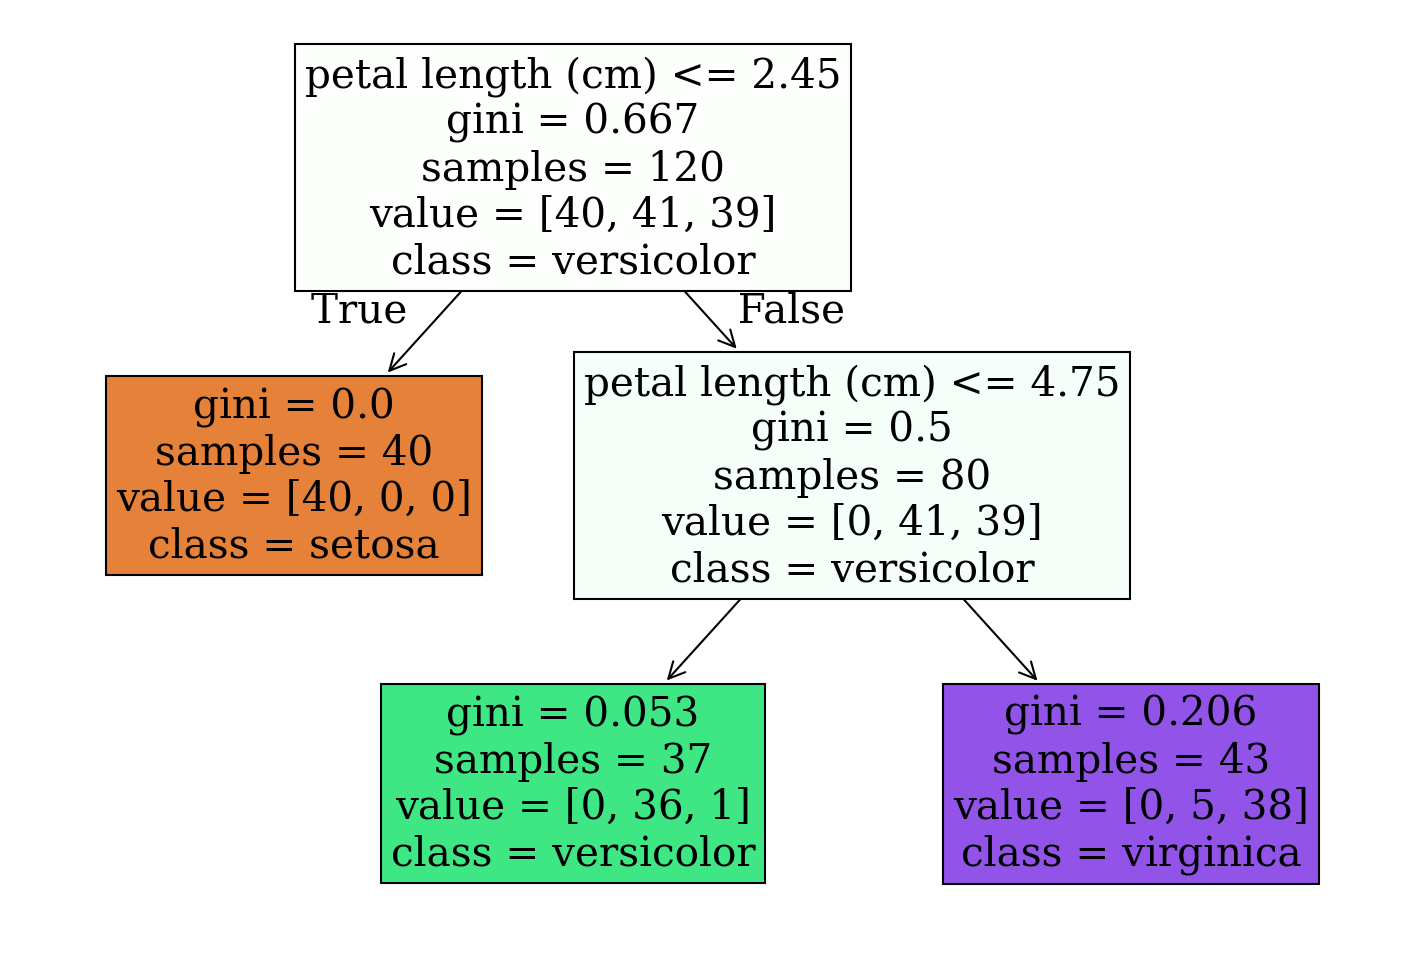

Accuracy: 0.97


In [8]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# Load data
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42
)

# Train and visualize
clf = DecisionTreeClassifier(max_depth=2, min_samples_leaf=5)
clf.fit(X_train, y_train)

plt.figure(figsize=(12,8))
plot_tree(clf, feature_names=iris.feature_names, 
          class_names=iris.target_names, filled=True)
plt.show()

# Evaluate
preds = clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, preds):.2f}")
